# Estilometría de Ajedrez - Single Channel CNN (Versión A)

Este notebook entrena una CNN siamesa con **imágenes combinadas** (tablero + heatmap).

In [1]:
# SETUP
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import cv2
import random
import tensorflow as tf
from pathlib import Path
from keras import layers, losses, optimizers, metrics, Model
from keras.applications import resnet
from collections import defaultdict

print("TF version:", tf.__version__)

# Configurar GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU configurada: {len(gpus)} dispositivo(s)")

# Parámetros
IMG_SHAPE = (192, 192)
BATCH_SIZE = 32
EPOCHS = 50
SEED = 314

# Reproducibilidad
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

2025-11-02 02:50:53.410638: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.20.0
GPU configurada: 1 dispositivo(s)


## 1. Descubrir Eventos Disponibles

### Primero escaneamos el PGN para ver qué tipos de eventos hay

In [2]:
# PASO 1: Descubrir eventos disponibles (VERSIÓN PARALELA)
sys.path.insert(0, str(Path('../').resolve()))
from event_discovery_parallel import ParallelEventDiscovery

pgn_file = Path('../dataset/generated/lichess_db.pgn')

print("Escaneando PGN para descubrir eventos...")
print("Usando procesamiento PARALELO (optimizado para RAM)\n")

# Versión PARALELA (10-20x más rápida)
discovery = ParallelEventDiscovery(pgn_file)  # Auto-limita workers según RAM disponible
events = discovery.discover_events(max_games=100000)  # Primeras 100k partidas
discovery.print_summary(events, top_n=15)

print("\n✓ Descubrimiento completado")
print(f"Total de eventos únicos: {len(events)}")

Escaneando PGN para descubrir eventos...
Usando procesamiento PARALELO (optimizado para RAM)


DESCUBRIMIENTO PARALELO DE EVENTOS (Optimizado RAM)
Archivo: ../dataset/generated/lichess_db.pgn
Workers: 72 (cores disponibles: 72)
RAM disponible: 114.9 GB
Límite: 100,000 partidas

Fase 1: Calculando límites de chunks...
  ✓ 72 chunks creados
  ✓ Tamaño total: 192864.9 MB
  ✓ ~2678.7 MB por chunk

Fase 2: Procesando chunks en paralelo...
(Usando streaming para minimizar uso de RAM)


Fase 3: Fusionando resultados...
  ✓ 100,008 partidas procesadas
  ✓ 1460 eventos únicos encontrados


TOP 15 EVENTOS MÁS COMUNES

#    Evento                                     Partidas  Jugadores
----------------------------------------------------------------------
1    Rated Blitz game                             42,393     72,244
2    Rated Bullet game                            33,602     50,827
3    Rated Rapid game                             14,051     25,663
4    Rated Classical game                

## 2. Seleccionar uno de los eventos encontrados (Usar blitz o Rapid)

In [3]:
SELECTED_EVENT = "Rated Rapid game"

if SELECTED_EVENT in events:
    event_stats = events[SELECTED_EVENT]
    print(f"\n✓ Evento seleccionado: {SELECTED_EVENT}")
    print(f"  Partidas disponibles: {event_stats['games']:,}")
    print(f"  Jugadores únicos: {event_stats['unique_players']:,}")
    print(f"  Victorias blancas: {event_stats['white_wins']:,}")
    print(f"  Victorias negras: {event_stats['black_wins']:,}")
    print(f"  Empates: {event_stats['draws']:,}")
else:
    print(f"\n⚠️ Evento '{SELECTED_EVENT}' no encontrado")
    print(f"Eventos disponibles: {list(events.keys())[:10]}")


✓ Evento seleccionado: Rated Rapid game
  Partidas disponibles: 14,051
  Jugadores únicos: 25,663
  Victorias blancas: 6,910
  Victorias negras: 6,466
  Empates: 647


## 3. Ejecutar Pipeline

In [4]:
from pipeline_stylometry_by_event import ChessStylometryPipelineByEvent

output_base = Path('./output')

# Crear pipeline CON EVENTO
pipeline = ChessStylometryPipelineByEvent(
    massive_pgn=pgn_file,
    output_base=output_base,
    event_type=SELECTED_EVENT,
    num_players=20,              # Jugadores a extraer
    games_per_player=30,         # Partidas por jugador
    min_threshold=0.7,           # 70% mínimo
    start_move=15,               # Movimiento inicial
    end_move=23,                 # Movimiento final
    compression_factor=1,        # Sin compresión
    use_relative_time=True       # Tiempos relativos
)

# EJECUTAR (puede tardar 10-20 minutos)
print("\n" + "="*70)
print("EJECUTANDO PIPELINE")
print("="*70)
print(f"Esto procesará SOLO partidas del evento: {SELECTED_EVENT}")
print(f"Leyendo PGN COMPLETO (sin límite de tiempo)\n")

stats = pipeline.run()

print("\n✓ Pipeline completado")
print(f"Jugadores procesados: {len(stats)}")
print(f"\nDirectorio de salida: {pipeline.event_dir}")


EJECUTANDO PIPELINE
Esto procesará SOLO partidas del evento: Rated Rapid game
Leyendo PGN COMPLETO (sin límite de tiempo)


######################################################################
# PIPELINE DE ESTILOMETRÍA POR EVENTO
######################################################################

Evento: Rated Rapid game
Output: output/events/Rated_Rapid_game

✓ JUGADORES YA EXTRAÍDOS (SALTANDO FASE 1)

Encontrados 14 jugadores en: output/events/Rated_Rapid_game/player_pgns
Saltando extracción de partidas (usar datos existentes)

  ✓ mrninjacat
  ✓ Mazette24
  ✓ Bot1nokk
  ✓ D v88
  ✓ wibron
  ✓ emperorofkicker
  ✓ vicio
  ✓ niravpjack1
  ✓ Khaledelmoniy
  ✓ iagow
  ✓ majedzaid
  ✓ mannequin99
  ✓ RaphaelKoci
  ✓ JakobFauxtreaux


FASE 2: GENERACIÓN SINCRONIZADA DE IMÁGENES
Sincronización: Garantiza tableros ↔ heatmaps 1:1

CPU cores disponibles: 72
Generación sincronizada para 14 jugadores

  ✓ mrninjacat:
      Partidas procesadas: 25
      Tableros: 225
      Heatmaps: 25
  

## 4. Descubrir Jugadores Procesados\n\nVer jugadores del evento seleccionado

In [5]:
# PASO 4: Descubrir jugadores procesados
# Buscar en el directorio del evento seleccionado

event_safe = SELECTED_EVENT.replace(" ", "_").replace("/", "_")
event_dir = output_base / "events" / event_safe

board_dir = event_dir / 'board_images'
heatmap_dir = event_dir / 'heatmap_images'

if not board_dir.exists():
    print(f"\n⚠️ Directorio no existe: {board_dir}")
    print("Ejecuta primero el pipeline")
else:
    players = sorted([d.name for d in board_dir.iterdir() if d.is_dir()])
    
    print(f"\nJugadores encontrados: {len(players)}")
    print(f"Evento: {SELECTED_EVENT}\n")
    
    for i, player in enumerate(players, 1):
        board_count = len(list((board_dir / player).glob('*.png')))
        heatmap_count = len(list((heatmap_dir / player).glob('*.png')))
        
        # Verificar sincronización
        board_games = {f.stem.split('_')[1] for f in (board_dir / player).glob('game_*.png')}
        heat_games = {f.stem.split('_')[1] for f in (heatmap_dir / player).glob('game_*.png')}
        synced = "✓" if board_games == heat_games else "⚠"
        
        print(f"  {i}. {player}")
        print(f"      Tableros: {board_count}, Heatmaps: {heatmap_count} {synced}")


Jugadores encontrados: 14
Evento: Rated Rapid game

  1. Bot1nokk
      Tableros: 216, Heatmaps: 24 ✓
  2. D_v88
      Tableros: 252, Heatmaps: 28 ✓
  3. JakobFauxtreaux
      Tableros: 225, Heatmaps: 25 ✓
  4. Khaledelmoniy
      Tableros: 243, Heatmaps: 27 ✓
  5. Mazette24
      Tableros: 162, Heatmaps: 18 ✓
  6. RaphaelKoci
      Tableros: 207, Heatmaps: 23 ✓
  7. emperorofkicker
      Tableros: 207, Heatmaps: 23 ✓
  8. iagow
      Tableros: 234, Heatmaps: 26 ✓
  9. majedzaid
      Tableros: 243, Heatmaps: 27 ✓
  10. mannequin99
      Tableros: 171, Heatmaps: 19 ✓
  11. mrninjacat
      Tableros: 225, Heatmaps: 25 ✓
  12. niravpjack1
      Tableros: 198, Heatmaps: 22 ✓
  13. vicio
      Tableros: 180, Heatmaps: 20 ✓
  14. wibron
      Tableros: 198, Heatmaps: 22 ✓


## 3. Función de Combinación de Imágenes

Combina tablero (escala de grises) con heatmap (térmico)

In [6]:
def combine_board_heatmap(board_path, heatmap_path, alpha=0.5):
    """
    Combina tablero y heatmap en una sola imagen.
    
    Parameters
    ----------
    board_path : Path
        Ruta a imagen de tablero
    heatmap_path : Path
        Ruta a heatmap
    alpha : float
        Peso del heatmap en la combinación (0-1)
    
    Returns
    -------
    np.ndarray
        Imagen combinada RGB normalizada [0, 1]
    """
    # Cargar imágenes
    board = cv2.imread(str(board_path), cv2.IMREAD_GRAYSCALE)
    heatmap = cv2.imread(str(heatmap_path), cv2.IMREAD_COLOR)
    
    if board is None or heatmap is None:
        raise ValueError(f"Error cargando: {board_path} o {heatmap_path}")
    
    # Redimensionar si es necesario
    if board.shape != IMG_SHAPE:
        board = cv2.resize(board, IMG_SHAPE)
    if heatmap.shape[:2] != IMG_SHAPE:
        heatmap = cv2.resize(heatmap, IMG_SHAPE)
    
    # Convertir tablero a RGB
    board_rgb = cv2.cvtColor(board, cv2.COLOR_GRAY2RGB)
    
    # Crear máscara de heatmap (donde hay datos)
    mask = (heatmap.sum(axis=2) > 0).astype(float)
    
    # Combinar: tablero base + heatmap superpuesto con alpha
    combined = board_rgb.astype(float) * (1 - alpha * mask[:,:,None])
    combined += heatmap.astype(float) * alpha * mask[:,:,None]
    
    # Normalizar a [0, 1]
    combined = combined / 255.0
    
    return combined.astype(np.float32)

print("✓ Función de combinación definida")

✓ Función de combinación definida


## 4. Previsualización de Datos

Visualizar ejemplos de imágenes combinadas


Jugador seleccionado: JakobFauxtreaux
  Tableros encontrados: 225
  Heatmaps encontrados: 25


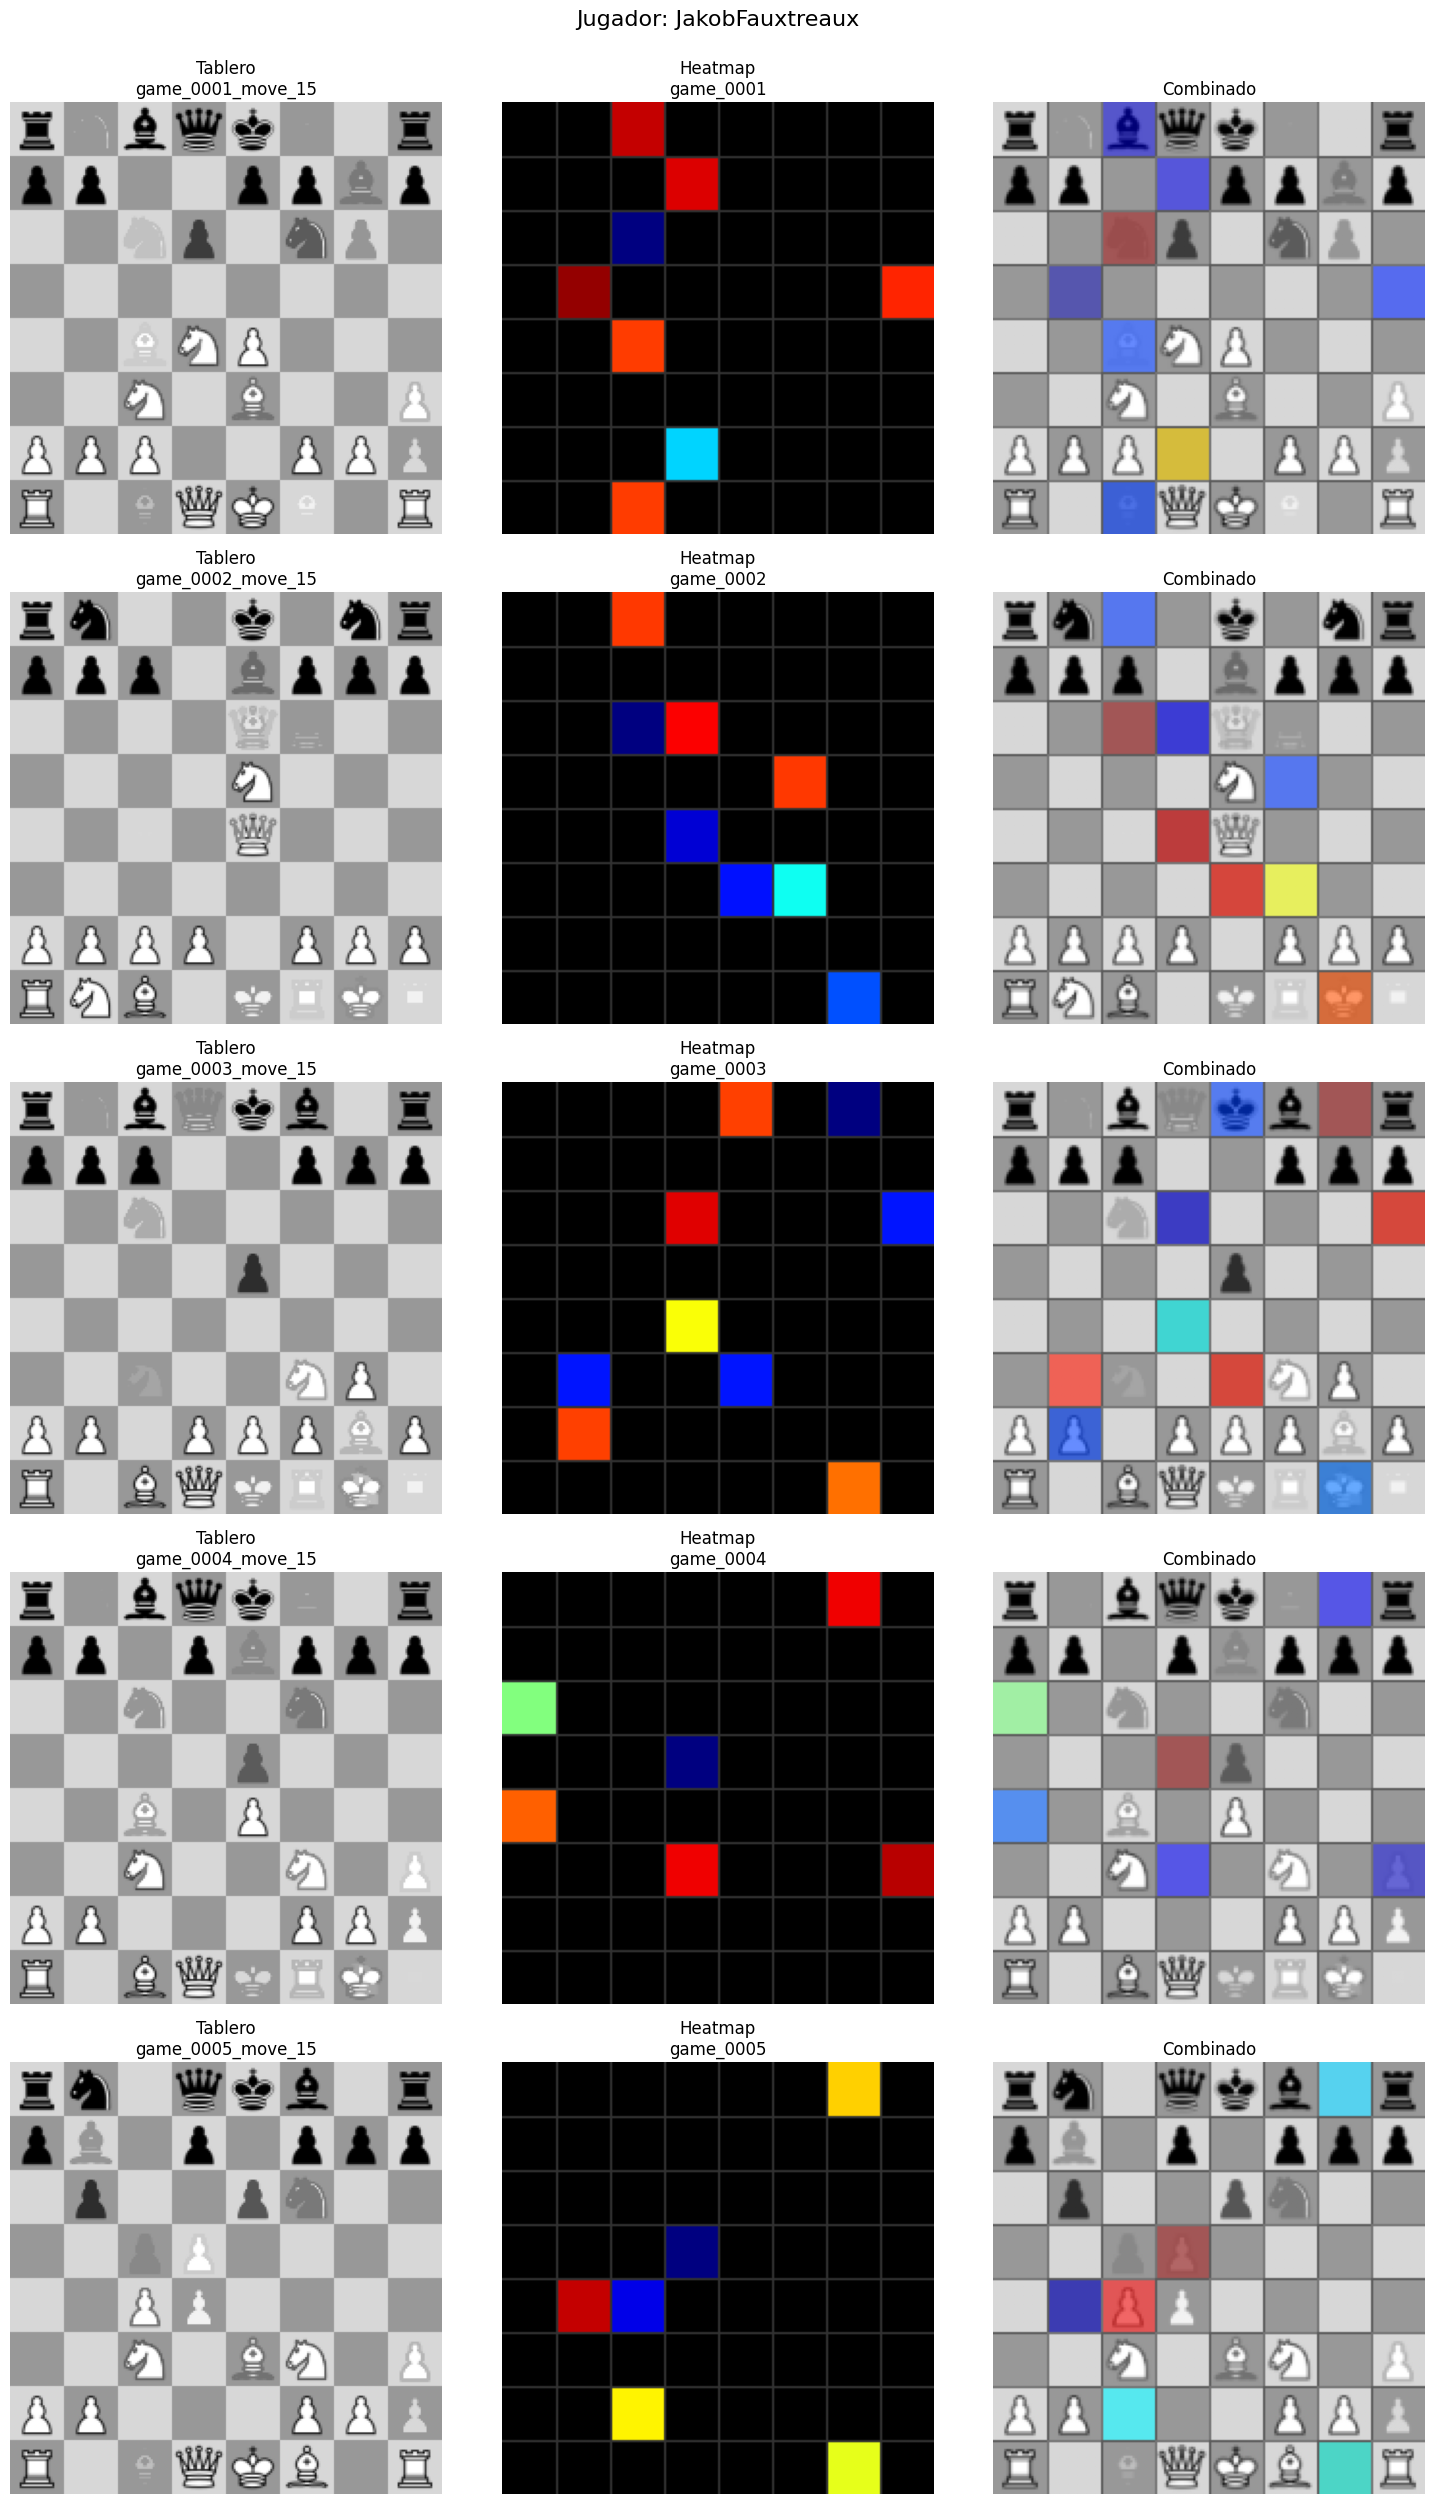


✓ Visualizadas 5 imágenes combinadas


In [7]:
# Seleccionar jugador aleatorio
player = random.choice(players)
player_board_dir = board_dir / player
player_heatmap_dir = heatmap_dir / player

# Obtener imágenes
board_imgs = sorted(list(player_board_dir.glob('*.png')))
heatmap_imgs = sorted(list(player_heatmap_dir.glob('*.png')))

print(f"\nJugador seleccionado: {player}")
print(f"  Tableros encontrados: {len(board_imgs)}")
print(f"  Heatmaps encontrados: {len(heatmap_imgs)}")

# Emparejar (misma partida)
pairs = []
for heat in heatmap_imgs[:5]:  # Primeras 5 partidas
    game_id = heat.stem.split('_')[1]  # Extraer game_XXXX
    matching_boards = [b for b in board_imgs if game_id in b.stem]
    if matching_boards:
        pairs.append((matching_boards[0], heat))

if len(pairs) == 0:
    print("\n⚠ No se encontraron pares tablero-heatmap para este jugador")
    print("Esto puede pasar si los nombres de archivo no coinciden.")
    print("Intentando con emparejamiento simple...")
    
    # Estrategia alternativa: emparejar por índice
    num_pairs = min(5, len(board_imgs), len(heatmap_imgs))
    for i in range(num_pairs):
        pairs.append((board_imgs[i], heatmap_imgs[i]))
    
    if len(pairs) == 0:
        print("\n❌ No hay imágenes para visualizar")
    else:
        print(f"\n✓ Emparejados {len(pairs)} pares por índice")

# Visualizar solo si hay pares
if len(pairs) > 0:
    fig, axes = plt.subplots(len(pairs), 3, figsize=(15, 5*len(pairs)))
    if len(pairs) == 1:
        axes = axes.reshape(1, -1)

    for i, (board_path, heat_path) in enumerate(pairs):
        # Cargar originales
        board_orig = cv2.imread(str(board_path))
        heat_orig = cv2.imread(str(heat_path))
        
        # Combinar
        combined = combine_board_heatmap(board_path, heat_path, alpha=0.6)
        
        # Mostrar
        axes[i, 0].imshow(cv2.cvtColor(board_orig, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f"Tablero\n{board_path.stem}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(cv2.cvtColor(heat_orig, cv2.COLOR_BGR2RGB))
        axes[i, 1].set_title(f"Heatmap\n{heat_path.stem}")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(combined)
        axes[i, 2].set_title("Combinado")
        axes[i, 2].axis('off')

    plt.suptitle(f"Jugador: {player}", fontsize=16, y=1.0)
    plt.tight_layout()
    plt.show()

    print(f"\n✓ Visualizadas {len(pairs)} imágenes combinadas")
else:
    print("\n⚠ Saltando visualización (no hay datos)")

## 5. Preparación del Dataset

Crear pares (tablero, heatmap) y organizarlos por jugador

In [8]:
# Construir dataset por jugador
dataset_by_player = {}

for player in players:
    player_board_dir = board_dir / player
    player_heatmap_dir = heatmap_dir / player
    
    # Obtener todas las imágenes
    board_imgs = sorted(list(player_board_dir.glob('*.png')))
    heatmap_imgs = sorted(list(player_heatmap_dir.glob('*.png')))
    
    # Emparejar por game_id
    pairs = []
    for heat in heatmap_imgs:
        game_id = heat.stem.split('_')[1]  # game_XXXX
        # Buscar tableros de esta partida
        matching_boards = [b for b in board_imgs if game_id in b.stem]
        
        if matching_boards:
            # Tomar un tablero aleatorio de la partida
            board = random.choice(matching_boards)
            pairs.append((board, heat))
    
    dataset_by_player[player] = pairs
    print(f"{player}: {len(pairs)} pares")

print(f"\n✓ Dataset preparado para {len(dataset_by_player)} jugadores")

Bot1nokk: 24 pares
D_v88: 28 pares
JakobFauxtreaux: 25 pares
Khaledelmoniy: 27 pares
Mazette24: 18 pares
RaphaelKoci: 23 pares
emperorofkicker: 23 pares
iagow: 26 pares
majedzaid: 27 pares
mannequin99: 19 pares
mrninjacat: 25 pares
niravpjack1: 22 pares
vicio: 20 pares
wibron: 22 pares

✓ Dataset preparado para 14 jugadores


## 6. Generación de Triplets

Crear triplets (anchor, positive, negative) para Triplet Loss

In [9]:
def generate_triplets(dataset_by_player, num_triplets=1000):
    """
    Genera triplets para entrenamiento.
    
    Returns
    -------
    triplets : list of tuples
        [(anchor_path_tuple, pos_path_tuple, neg_path_tuple), ...]
    """
    triplets = []
    
    # FILTRAR jugadores con al menos 2 pares
    valid_players = {p: pairs for p, pairs in dataset_by_player.items() if len(pairs) >= 2}
    
    if len(valid_players) < 2:
        print(f"\n⚠ ERROR: Se necesitan al menos 2 jugadores con 2+ pares")
        print(f"  Jugadores válidos: {len(valid_players)}")
        print(f"  Mínimo requerido: 2")
        return []
    
    player_names = list(valid_players.keys())
    print(f"\nJugadores válidos para triplets: {len(player_names)}/{len(dataset_by_player)}")
    
    attempts = 0
    max_attempts = num_triplets * 10  # Evitar loop infinito
    
    while len(triplets) < num_triplets and attempts < max_attempts:
        attempts += 1
        
        # Seleccionar jugador anchor
        anchor_player = random.choice(player_names)
        anchor_pairs = valid_players[anchor_player]
        
        # Anchor y positive del mismo jugador
        anchor_pair, pos_pair = random.sample(anchor_pairs, 2)
        
        # Negative de otro jugador (asegurar que tenga pares)
        other_players = [p for p in player_names if p != anchor_player]
        if not other_players:
            continue
        
        neg_player = random.choice(other_players)
        neg_pairs = valid_players[neg_player]
        
        if len(neg_pairs) == 0:
            continue
        
        neg_pair = random.choice(neg_pairs)
        
        triplets.append((anchor_pair, pos_pair, neg_pair))
    
    if len(triplets) < num_triplets:
        print(f"\n⚠ Solo se generaron {len(triplets)}/{num_triplets} triplets")
        print(f"  Esto puede pasar si hay pocos jugadores o pares")
    
    return triplets

# Generar triplets
NUM_TRAIN = 2000
NUM_VAL = 500

train_triplets = generate_triplets(dataset_by_player, NUM_TRAIN)
val_triplets = generate_triplets(dataset_by_player, NUM_VAL)

print(f"\nTriplets generados:")
print(f"  Train: {len(train_triplets)}")
print(f"  Val:   {len(val_triplets)}")


Jugadores válidos para triplets: 14/14

Jugadores válidos para triplets: 14/14

Triplets generados:
  Train: 2000
  Val:   500


In [10]:
def triplet_generator(triplets, batch_size=32, shuffle=True):
    """
    Generador de batches de triplets.
    
    Yields
    ------
    (anchor_batch, pos_batch, neg_batch)
    """
    while True:
        if shuffle:
            random.shuffle(triplets)
        
        for i in range(0, len(triplets), batch_size):
            batch = triplets[i:i+batch_size]
            
            anchors = []
            positives = []
            negatives = []
            
            for anchor_pair, pos_pair, neg_pair in batch:
                # Combinar imágenes
                anchor_img = combine_board_heatmap(anchor_pair[0], anchor_pair[1])
                pos_img = combine_board_heatmap(pos_pair[0], pos_pair[1])
                neg_img = combine_board_heatmap(neg_pair[0], neg_pair[1])
                
                anchors.append(anchor_img)
                positives.append(pos_img)
                negatives.append(neg_img)
            
            yield (
                np.array(anchors),
                np.array(positives),
                np.array(negatives)
            )

print("✓ Generador de triplets definido")

✓ Generador de triplets definido


## 7. Modelo Single Channel

CNN Siamesa con imagen combinada como entrada

In [11]:
class SingleChannelEmbedding(Model):
    """
    Encoder de imagen combinada (tablero + heatmap).
    """
    def __init__(self):
        super().__init__()
        
        # Encoder único para imagen combinada
        base_cnn = resnet.ResNet50(
            weights="imagenet",
            input_shape=IMG_SHAPE + (3,),
            include_top=False
        )
        
        # Congelar las primeras capas
        for layer in base_cnn.layers[:-10]:
            layer.trainable = False
        
        self.encoder = tf.keras.Sequential([
            base_cnn,
            layers.GlobalAveragePooling2D(),
            layers.Dense(512, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(128)
        ], name="single_encoder")
    
    def call(self, combined_img):
        emb = self.encoder(combined_img)
        return tf.nn.l2_normalize(emb, axis=1)

embedding_model = SingleChannelEmbedding()
print("✓ Modelo Single Channel creado")
print(f"  Parámetros totales: {embedding_model.encoder.count_params():,}")

I0000 00:00:1762052377.085565 1900576 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22502 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:02:00.0, compute capability: 8.6


✓ Modelo Single Channel creado
  Parámetros totales: 24,804,096


In [12]:
class SiameseModel(Model):
    """
    Modelo Siamés con Triplet Loss.
    """
    def __init__(self, embedding_model, margin=1.0):
        super().__init__()
        self.embedding_model = embedding_model
        self.margin = margin
        self.loss_tracker = metrics.Mean(name="loss")
    
    def call(self, inputs):
        anchor, positive, negative = inputs
        anchor_emb = self.embedding_model(anchor)
        pos_emb = self.embedding_model(positive)
        neg_emb = self.embedding_model(negative)
        return anchor_emb, pos_emb, neg_emb
    
    def train_step(self, data):
        anchor, positive, negative = data
        
        with tf.GradientTape() as tape:
            # Forward pass
            anchor_emb, pos_emb, neg_emb = self([anchor, positive, negative])
            
            # Triplet loss
            pos_dist = tf.reduce_sum(tf.square(anchor_emb - pos_emb), axis=1)
            neg_dist = tf.reduce_sum(tf.square(anchor_emb - neg_emb), axis=1)
            loss = tf.maximum(pos_dist - neg_dist + self.margin, 0.0)
            loss = tf.reduce_mean(loss)
        
        # Backward pass
        gradients = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))
        
        # Update metrics
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}
    
    @property
    def metrics(self):
        return [self.loss_tracker]

# Crear modelo
siamese_model = SiameseModel(embedding_model, margin=1.0)
siamese_model.compile(optimizer=optimizers.Adam(learning_rate=1e-4))

print("✓ Modelo Siamés compilado")

✓ Modelo Siamés compilado


## 8. Entrenamiento

Entrenar con Triplet Loss

In [13]:
# Generadores
train_gen = triplet_generator(train_triplets, BATCH_SIZE, shuffle=True)
val_gen = triplet_generator(val_triplets, BATCH_SIZE, shuffle=False)

# Callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_model_single_channel.keras',
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Entrenar
history = siamese_model.fit(
    train_gen,
    steps_per_epoch=len(train_triplets) // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Entrenamiento completado")

Epoch 1/50


2025-11-02 03:00:19.007693: I external/local_xla/xla/service/service.cc:163] XLA service 0x714708017210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-02 03:00:19.007732: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2025-11-02 03:00:19.853563: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-02 03:00:26.791652: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-11-02 03:00:27.500511: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-02 03:00:27.500568: I external

 2/62 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 1.0002  

I0000 00:00:1762052441.091502 1910933 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - loss: 0.9992
Epoch 1: loss improved from None to 0.99901, saving model to best_model_single_channel.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 69s 383ms/step - loss: 0.9990 - learning_rate: 1.0000e-04
Epoch 2/50


2025-11-02 03:01:10.219999: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-02 03:01:10.220046: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-02 03:01:10.680343: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 4 bytes spill stores, 4 bytes spill loads

2025-11-02 03:01:11.125175: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Regi

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - loss: 0.9982
Epoch 2: loss did not improve from 0.99901
62/62 ━━━━━━━━━━━━━━━━━━━━ 35s 348ms/step - loss: 0.9993 - learning_rate: 1.0000e-04
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - loss: 0.9983
Epoch 3: loss did not improve from 0.99901
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 351ms/step - loss: 0.9991 - learning_rate: 1.0000e-04
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - loss: 1.0000
Epoch 4: loss did not improve from 0.99901
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 353ms/step - loss: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - loss: 0.9978
Epoch 5: loss improved from 0.99901 to 0.99797, saving model to best_model_single_channel.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 24s 386ms/step - loss: 0.9980 - learning_rate: 1.0000e-04
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - loss: 0.9999
Epoch 6: loss did not improve from 0.99797
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 347ms/step - loss: 0.9989 - learning_

## 9. Visualización del Entrenamiento

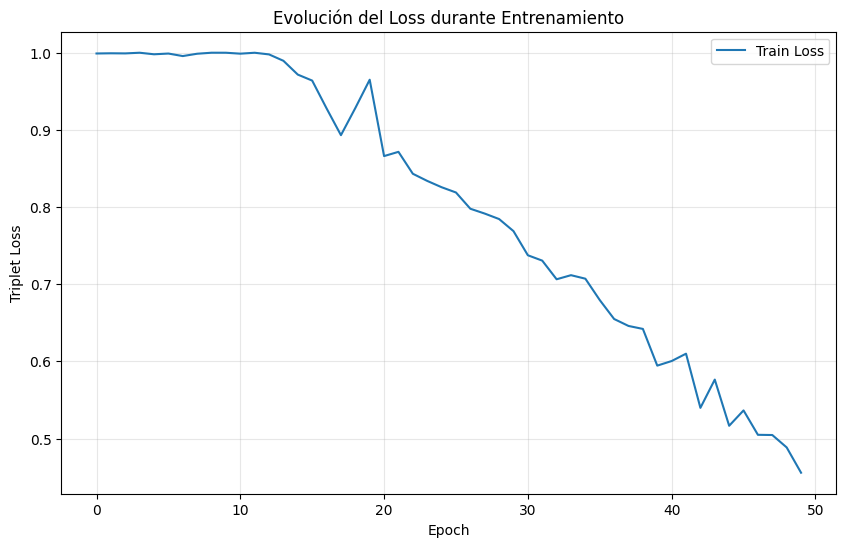

In [14]:
# Curva de loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Triplet Loss')
plt.title('Evolución del Loss durante Entrenamiento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Evaluación

Calcular distancias entre embeddings

In [15]:
# Generar embeddings de validación
val_anchors = []
val_positives = []
val_negatives = []

for anchor_pair, pos_pair, neg_pair in val_triplets[:100]:
    anchor_img = combine_board_heatmap(anchor_pair[0], anchor_pair[1])
    pos_img = combine_board_heatmap(pos_pair[0], pos_pair[1])
    neg_img = combine_board_heatmap(neg_pair[0], neg_pair[1])
    
    val_anchors.append(anchor_img)
    val_positives.append(pos_img)
    val_negatives.append(neg_img)

val_anchors = np.array(val_anchors)
val_positives = np.array(val_positives)
val_negatives = np.array(val_negatives)

# Calcular embeddings
anchor_embs = embedding_model(val_anchors)
pos_embs = embedding_model(val_positives)
neg_embs = embedding_model(val_negatives)

# Distancias
pos_dists = tf.reduce_sum(tf.square(anchor_embs - pos_embs), axis=1).numpy()
neg_dists = tf.reduce_sum(tf.square(anchor_embs - neg_embs), axis=1).numpy()

print(f"\nDistancias anchor↔positive:")
print(f"  Media: {pos_dists.mean():.4f}")
print(f"  Std:   {pos_dists.std():.4f}")

print(f"\nDistancias anchor↔negative:")
print(f"  Media: {neg_dists.mean():.4f}")
print(f"  Std:   {neg_dists.std():.4f}")

print(f"\nRatio (neg/pos): {neg_dists.mean() / pos_dists.mean():.2f}x")
print(f"Separación deseada: >1.5x")


Distancias anchor↔positive:
  Media: 0.6281
  Std:   0.5973

Distancias anchor↔negative:
  Media: 1.7521
  Std:   1.0255

Ratio (neg/pos): 2.79x
Separación deseada: >1.5x


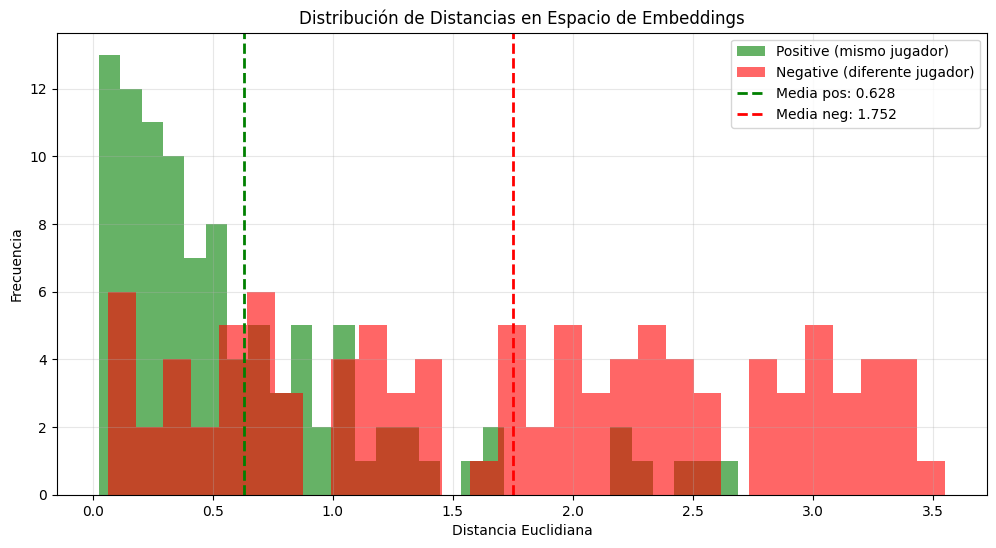


✓ ¡Buena separación! El modelo distingue estilos


In [16]:
# Histograma comparativo
plt.figure(figsize=(12, 6))

plt.hist(pos_dists, bins=30, alpha=0.6, label='Positive (mismo jugador)', color='green')
plt.hist(neg_dists, bins=30, alpha=0.6, label='Negative (diferente jugador)', color='red')

plt.axvline(pos_dists.mean(), color='green', linestyle='--', linewidth=2, label=f'Media pos: {pos_dists.mean():.3f}')
plt.axvline(neg_dists.mean(), color='red', linestyle='--', linewidth=2, label=f'Media neg: {neg_dists.mean():.3f}')

plt.xlabel('Distancia Euclidiana')
plt.ylabel('Frecuencia')
plt.title('Distribución de Distancias en Espacio de Embeddings')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Interpretar
if pos_dists.mean() < neg_dists.mean():
    print("\n✓ ¡Buena separación! El modelo distingue estilos")
else:
    print("\n⚠ Separación insuficiente. Entrenar más o ajustar hyperparámetros")

## 11. Matriz de Distancias entre Jugadores

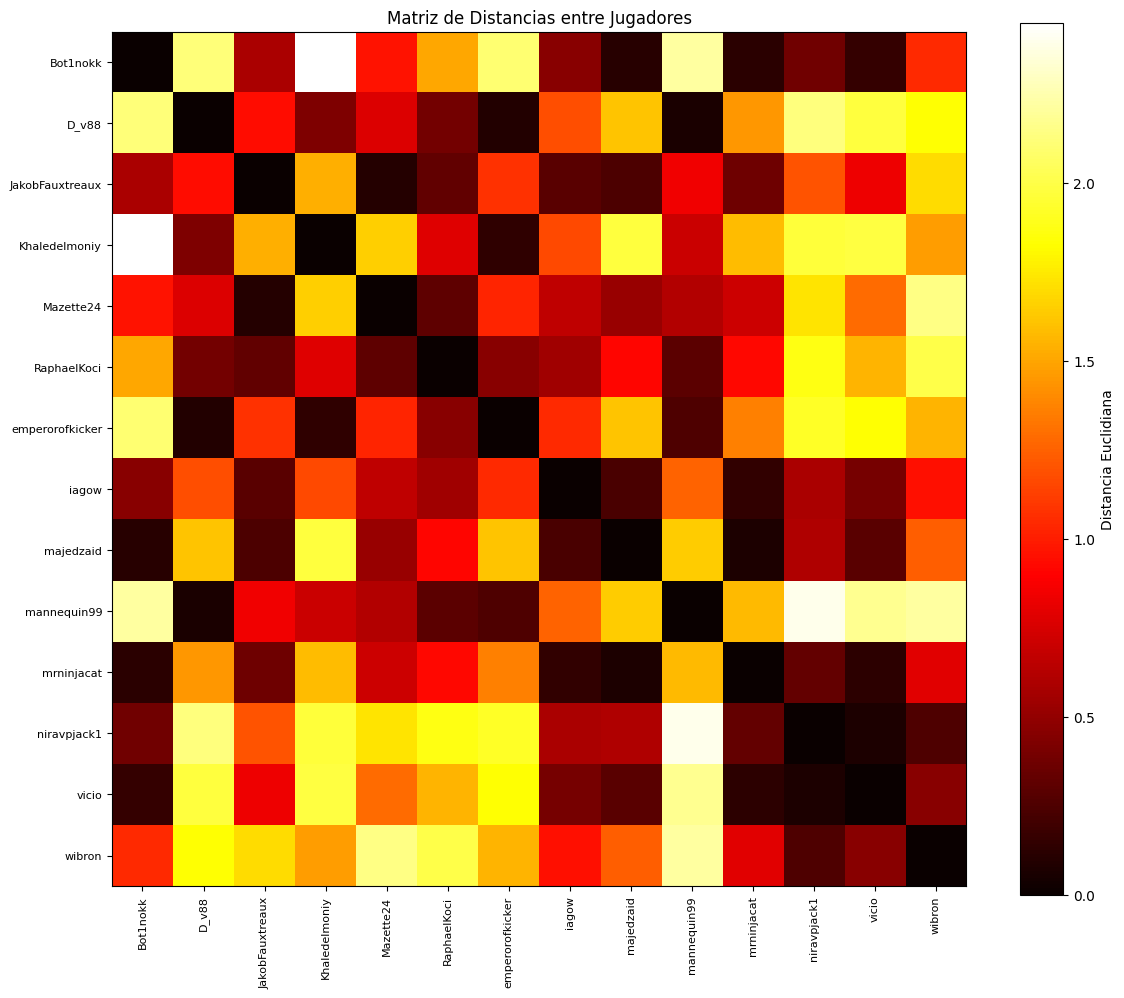


✓ Matriz de distancias generada

Jugadores más similares (distancia baja):
  Bot1nokk ↔ iagow: 0.459
  Bot1nokk ↔ majedzaid: 0.108
  Bot1nokk ↔ mrninjacat: 0.119
  Bot1nokk ↔ niravpjack1: 0.373
  Bot1nokk ↔ vicio: 0.156
  D_v88 ↔ Khaledelmoniy: 0.430
  D_v88 ↔ RaphaelKoci: 0.390
  D_v88 ↔ emperorofkicker: 0.092
  D_v88 ↔ mannequin99: 0.060
  JakobFauxtreaux ↔ Mazette24: 0.097
  JakobFauxtreaux ↔ RaphaelKoci: 0.321
  JakobFauxtreaux ↔ iagow: 0.292
  JakobFauxtreaux ↔ majedzaid: 0.240
  JakobFauxtreaux ↔ mrninjacat: 0.366


In [17]:
# Calcular embedding promedio por jugador
player_embeddings = {}

for player in players:
    pairs = dataset_by_player[player][:10]  # Primeras 10 partidas
    embeddings = []
    
    for board_path, heat_path in pairs:
        combined = combine_board_heatmap(board_path, heat_path)
        emb = embedding_model(combined[np.newaxis, ...])
        embeddings.append(emb.numpy())
    
    player_embeddings[player] = np.mean(embeddings, axis=0)

# Matriz de distancias
n_players = len(players)
dist_matrix = np.zeros((n_players, n_players))

for i, player1 in enumerate(players):
    for j, player2 in enumerate(players):
        dist = np.sum((player_embeddings[player1] - player_embeddings[player2])**2)
        dist_matrix[i, j] = dist

# Visualizar
plt.figure(figsize=(12, 10))
plt.imshow(dist_matrix, cmap='hot', interpolation='nearest')
plt.colorbar(label='Distancia Euclidiana')
plt.xticks(range(n_players), [p[:15] for p in players], rotation=90, fontsize=8)
plt.yticks(range(n_players), [p[:15] for p in players], fontsize=8)
plt.title('Matriz de Distancias entre Jugadores')
plt.tight_layout()
plt.show()

print("\n✓ Matriz de distancias generada")
print("\nJugadores más similares (distancia baja):")
for i in range(min(3, n_players)):
    for j in range(i+1, n_players):
        if dist_matrix[i, j] < 0.5:  # Threshold
            print(f"  {players[i]} ↔ {players[j]}: {dist_matrix[i, j]:.3f}")

## 12. Conclusiones

### Versión A (Single Channel)

**Pros**:
- ⚡ Rápida (~30 seg/epoch)
- 💾 Poca memoria (~2 GB GPU)
- 🔧 Simple de implementar

**Contras**:
- 📉 Pérdida de información al combinar
- 🎯 Menor capacidad de aprendizaje

**Próximos Pasos**:
1. Comparar con Versión B (Dual Channel)
2. Experimentar con diferentes valores de `alpha` en combinación
3. Data augmentation (rotaciones, flips)
4. Fine-tuning de ResNet50 completo